<a href="https://colab.research.google.com/github/Simaycims/-datasciencecoursera/blob/master/Churn_Thesis_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Gerekli kütüphaneyi içeri aktarıyoruz
import pandas as pd

# sheet_name=1 komutu ile Excel'in 2. sekmesindeki asıl verileri okutuyoruz
# DİKKAT: Dosya adını yine kendi dosyanızın adıyla değiştirmeyi unutmayın.
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name=1)

# Veri setinin ilk 5 satırını ekrana yazdıralım
print("Asıl Veri Setinin İlk 5 Satırı:")
display(df.head())

# Verimizde toplam kaç satır/sütun var bakalım
print("\n--- Asıl Veri Seti Özeti ---")
df.info()

Asıl Veri Setinin İlk 5 Satırı:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60



--- Asıl Veri Seti Özeti ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   o

In [ ]:
# 1. Modele bir katkısı olmayan (sadece kimlik numarası olan) sütunu siliyoruz
df = df.drop('CustomerID', axis=1)

# 2. Eksik (NaN) verileri bilimsel yöntemle dolduruyoruz:
# Sayısal verileri ortanca (medyan) ile, metin (kategorik) verileri en çok tekrar eden (mod) ile dolduruyoruz.
for col in df.columns:
    if df[col].dtype == 'object': # Eğer sütun metin ise
        df[col].fillna(df[col].mode()[0], inplace=True)
    else: # Eğer sütun sayısal ise
        df[col].fillna(df[col].median(), inplace=True)

# 3. Verinin son durumunu kontrol ediyoruz
print("Kalan Toplam Eksik Veri Sayısı:", df.isnull().sum().sum())
print("Temizlenmiş Veri Setinin Boyutu:", df.shape)

Kalan Toplam Eksik Veri Sayısı: 0
Temizlenmiş Veri Setinin Boyutu: (5630, 19)


/tmp/ipykernel_733/2355546212.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_733/2355546212.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Metin (Kategorik) verileri bilgisayarın anlayacağı 1 ve 0'lara çeviriyoruz
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. X (Özellikler) ve y (Hedef/Churn) olarak veriyi ayırıyoruz
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 3. Modeli eğitmek ve test etmek için veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Veri analize hazır hale getirildi!")
print("Eğitim (Train) Seti Boyutu:", X_train.shape)
print("Test Seti Boyutu:", X_test.shape)

Veri analize hazır hale getirildi!
Eğitim (Train) Seti Boyutu: (4504, 29)
Test Seti Boyutu: (1126, 29)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Modeli Tanımlıyoruz (Yapay Zekanın Kurulması)
# random_state=42: Sonuçların her çalıştırdığımızda tutarlı ve aynı çıkmasını sağlar
rf_model = RandomForestClassifier(random_state=42)

# 2. Modeli Eğitiyoruz (4504 satırlık eğitim verisiyle sistemi öğretiyoruz)
print("Yapay Zeka eğitiliyor, lütfen bekleyin...\n")
rf_model.fit(X_train, y_train)

# 3. Modelden Test Seti Üzerinde Tahmin Yapmasını İstiyoruz (1126 satırlık görmediği veri)
y_pred = rf_model.predict(X_test)

# 4. Sonuçları Değerlendiriyoruz (Modelin Karnesi)
dogruluk_orani = accuracy_score(y_test, y_pred)

print("--- RANDOM FOREST MODEL KARNESİ ---")
print(f"Genel Doğruluk Oranı (Accuracy): % {dogruluk_orani * 100:.2f}\n")

print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

Yapay Zeka eğitiliyor, lütfen bekleyin...

--- RANDOM FOREST MODEL KARNESİ ---
Genel Doğruluk Oranı (Accuracy): % 96.98

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       941
           1       0.99      0.82      0.90       185

    accuracy                           0.97      1126
   macro avg       0.98      0.91      0.94      1126
weighted avg       0.97      0.97      0.97      1126



/tmp/ipykernel_733/3603321516.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Derecesi', y='Özellikler', data=importance_df, palette='viridis')


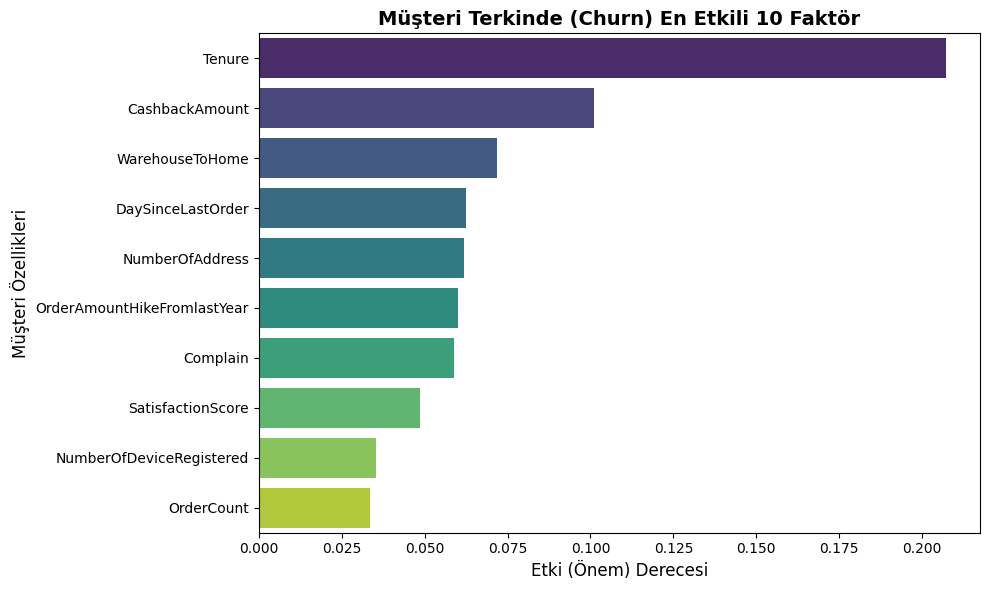

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Modelin içinden özelliklerin (faktörlerin) önem derecelerini alıyoruz
feature_importances = rf_model.feature_importances_

# 2. Bu oranları sütun isimlerimizle eşleştirip bir tablo yapıyoruz
importance_df = pd.DataFrame({
    'Özellikler': X.columns,
    'Önem Derecesi': feature_importances
})

# 3. En önemli 10 faktörü büyükten küçüğe sıralıyoruz
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False).head(10)

# 4. Jüri sunumu için şık ve renkli bir grafik çizdiriyoruz
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellikler', data=importance_df, palette='viridis')

# Grafiğin başlık ve etiket ayarları
plt.title('Müşteri Terkinde (Churn) En Etkili 10 Faktör', fontsize=14, fontweight='bold')
plt.xlabel('Etki (Önem) Derecesi', fontsize=12)
plt.ylabel('Müşteri Özellikleri', fontsize=12)
plt.tight_layout()

# Grafiği ekranda göster
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. XGBoost Modelini Tanımlıyoruz
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Modeli Eğitiyoruz
print("XGBoost Modeli eğitiliyor, lütfen bekleyin...\n")
xgb_model.fit(X_train, y_train)

# 3. Test Seti Üzerinde Tahmin Yapıyoruz
y_pred_xgb = xgb_model.predict(X_test)
xgb_dogruluk = accuracy_score(y_test, y_pred_xgb)

# 4. İki Modeli Karşılaştıran "Jüri Tablosu"nu Yazdırıyoruz
print("--- 🏆 MODELLERİN KARŞILAŞTIRMA SONUCU 🏆 ---")
print(f"1. Random Forest Doğruluk Oranı: % {dogruluk_orani * 100:.2f}")
print(f"2. XGBoost Doğruluk Oranı      : % {xgb_dogruluk * 100:.2f}\n")

print("XGBoost Detaylı Rapor:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Modeli eğitiliyor, lütfen bekleyin...

--- 🏆 MODELLERİN KARŞILAŞTIRMA SONUCU 🏆 ---
1. Random Forest Doğruluk Oranı: % 96.98
2. XGBoost Doğruluk Oranı      : % 97.96

XGBoost Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       941
           1       0.97      0.90      0.94       185

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/tmp/ipykernel_733/1063792093.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Derecesi', y='Özellikler', data=xgb_importance_df, palette='magma')


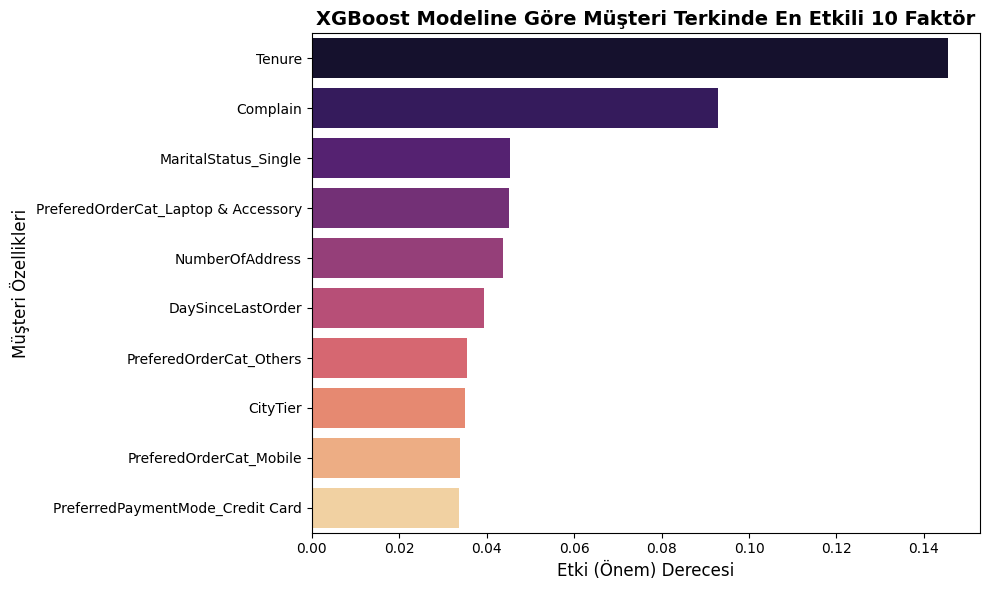

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. XGBoost modelinin içinden özelliklerin önem derecelerini alıyoruz
xgb_importances = xgb_model.feature_importances_

# 2. Bu oranları sütun isimlerimizle eşleştirip tablo yapıyoruz
xgb_importance_df = pd.DataFrame({
    'Özellikler': X.columns,
    'Önem Derecesi': xgb_importances
})

# 3. En önemli 10 faktörü büyükten küçüğe sıralıyoruz
xgb_importance_df = xgb_importance_df.sort_values(by='Önem Derecesi', ascending=False).head(10)

# 4. Jüri sunumu için şık ve renkli bir grafik çizdiriyoruz (XGBoost'a Özel)
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellikler', data=xgb_importance_df, palette='magma')

# Grafiğin başlık ve etiket ayarları
plt.title('XGBoost Modeline Göre Müşteri Terkinde En Etkili 10 Faktör', fontsize=14, fontweight='bold')
plt.xlabel('Etki (Önem) Derecesi', fontsize=12)
plt.ylabel('Müşteri Özellikleri', fontsize=12)
plt.tight_layout()

# Grafiği ekranda göster
plt.show()

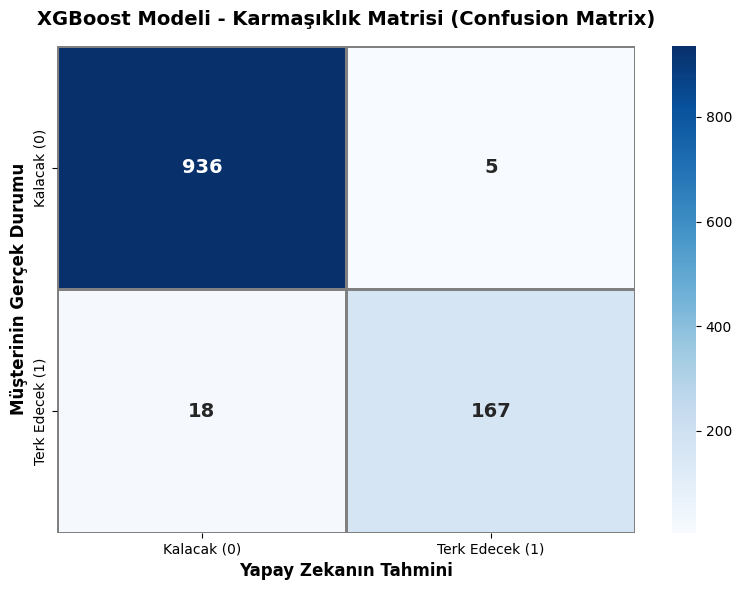

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. XGBoost modelimizin tahminleri ile gerçek sonuçları karşılaştırarak matrisi oluşturuyoruz
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Matrisi renklendirip şık bir ısı haritasına (heatmap) çeviriyoruz
plt.figure(figsize=(8, 6))
# fmt='d': Sayıların ondalıklı değil tam sayı görünmesini sağlar, cmap='Blues': Mavi tonlarında renklendirir
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='gray',
            xticklabels=['Kalacak (0)', 'Terk Edecek (1)'],
            yticklabels=['Kalacak (0)', 'Terk Edecek (1)'],
            annot_kws={"size": 14, "weight": "bold"})

# Grafiğin başlık ve eksen ayarları
plt.title('XGBoost Modeli - Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Yapay Zekanın Tahmini', fontsize=12, fontweight='bold')
plt.ylabel('Müşterinin Gerçek Durumu', fontsize=12, fontweight='bold')
plt.tight_layout()

# Grafiği ekranda göster
plt.show()

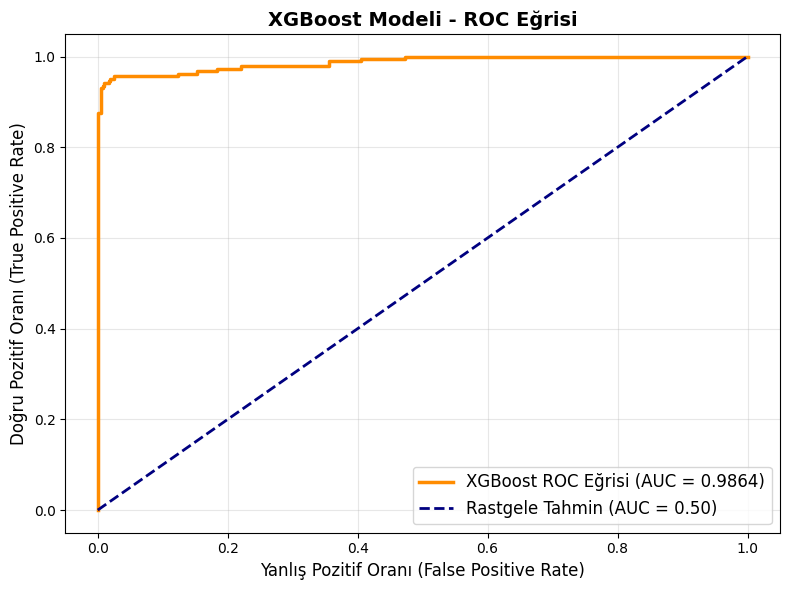

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Modelin sadece 1 veya 0 demesini değil, "yüzde kaç ihtimalle" 1 dediğini (olasılıkları) alıyoruz
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. ROC eğrisi için gerekli olan Yanlış Pozitif (FPR) ve Doğru Pozitif (TPR) oranlarını hesaplıyoruz
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Eğrinin Altında Kalan Alanı (AUC - Area Under Curve) hesaplıyoruz
roc_auc = auc(fpr, tpr)

# 4. Şık bir ROC Eğrisi grafiği çizdiriyoruz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'XGBoost ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = 0.50)')

# Grafiğin başlık, eksen ve lejant ayarları
plt.title('XGBoost Modeli - ROC Eğrisi', fontsize=14, fontweight='bold')
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Grafiği ekranda göster
plt.show()

SHAP değerleri hesaplanıyor, bu işlem birkaç saniye sürebilir...



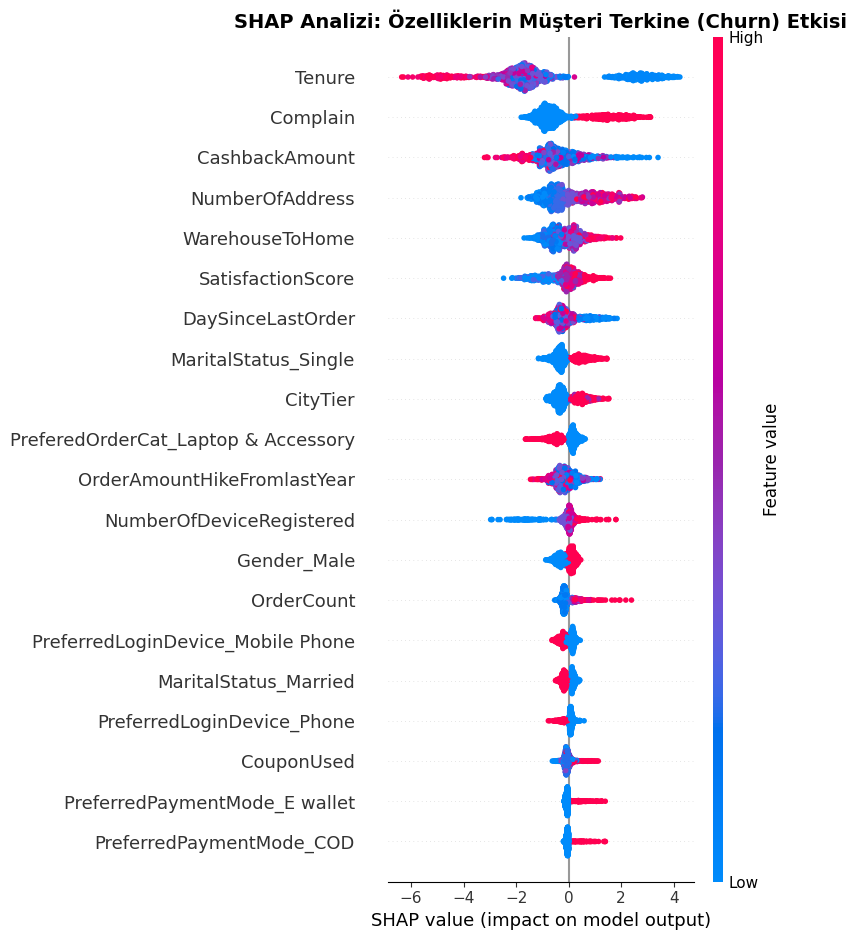

In [ ]:
# Eğer Colab'de SHAP yüklü değilse diye önce kuruyoruz
!pip install shap

import shap
import matplotlib.pyplot as plt

print("SHAP değerleri hesaplanıyor, bu işlem birkaç saniye sürebilir...\n")

# 1. XGBoost modelimizin beynini okuyacak "Açıklayıcı"yı (Explainer) kuruyoruz
explainer = shap.TreeExplainer(xgb_model)

# 2. Test setindeki 1126 müşterinin her biri için SHAP değerlerini hesaplıyoruz
shap_values = explainer.shap_values(X_test)

# 3. O meşhur ve rengarenk SHAP Özet Grafiğini (Summary Plot) çizdiriyoruz
plt.figure(figsize=(10, 6))
plt.title("SHAP Analizi: Özelliklerin Müşteri Terkine (Churn) Etkisi", fontsize=14, fontweight='bold')

# Grafiği oluştur (show=False diyerek üstüne başlık eklememizi sağlıyoruz)
shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.show()